**Import the Packages**

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
import pandas as pd

from math import sqrt
from sklearn.model_selection import KFold, cross_val_score

import optuna
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


from sklearn.linear_model import Lasso
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline



# import warnings
# warnings.filterwarnings('ignore')

# pd.pandas.set_option('display.max_columns', None)

**Load the Datasets**

In [28]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")
sample_submission = pd.read_csv("./data/sample_submission.csv")

print("train data shape is {}".format(df_train.shape))
print("test data shape is {}".format(df_test.shape))
print("sample_submission data shape is {}".format(sample_submission.shape))

train data shape is (1460, 81)
test data shape is (1459, 80)
sample_submission data shape is (1459, 2)


**Check the Data**

In [164]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [165]:
# Check for duplicates in train set
df_train.duplicated().sum()

np.int64(0)

**Target Feature Distribution**

Find out the distribution of the target feature

/tmp/ipykernel_2674/3676897673.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_train.get('SalePrice'), kde=False)


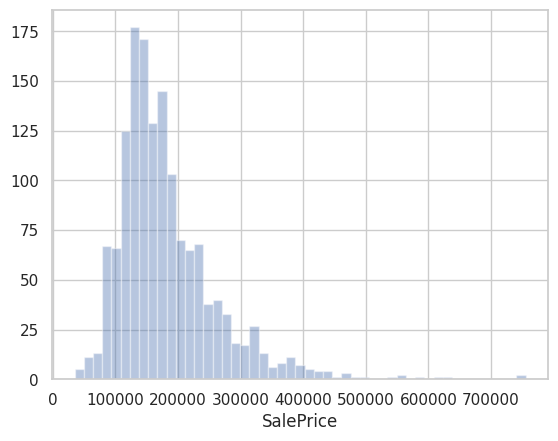

In [166]:
# Distribution of values in target feature
sns.distplot(df_train.get('SalePrice'), kde=False)
plt.show()

The dependent feature 'SalePrice' is right-skewed, we will have to perform a log-normal transformation on this feature.

**Outliers**

In [ ]:
# Find outliers for all the numerical dataset (before handling missing values)

numerical_df = df_train.select_dtypes(exclude=['object'])
numerical_df = numerical_df.drop(["Id"], axis=1)

for column in numerical_df:
    plt.figure(figsize=(16, 4))
    sns.set_theme(style='whitegrid')
    sns.boxplot(numerical_df[column], orient='h')
    plt.xlabel(column)
    plt.show()

From the images above, it can be inferred that there are outliers in the data. We will not delete the rows containing the outliers for
the changes that it might destroy some important data. The outliers will have to be handled later.

**Merge the datasets**

Combine the two datasets to do the pre-processing on before splitting it up again for the models

In [29]:
# Merge the dataframes together
df = pd.concat([df_train, df_test])
  
# Reset the index
df.reset_index(drop=True, inplace=True)

df.shape

(2919, 81)

In [169]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


**Fill in Missing Data**

Go through each feature and fill in the missing data.

Numerical: 
- Fill in missing data with either 0 (which represents "None"), the mean or the mode, whichever makes more sense. Except for SalePrice.

Categorical:
- Fill in the data with "None" if it seems that it makes sense. Otherwise, fill it in with the mode.

In [ ]:
# Find out missing rows
df.isnull().sum().sort_values(ascending=False).head(36)

In [30]:
# %%
# Dictionnaire des colonnes et valeurs de remplacement
fill_values = {
    'PoolQC': 'None',
    'MiscFeature': 'None',
    'Alley': 'None',
    'Fence': 'None',
    'MasVnrType': 'None',
    'FireplaceQu': 'None',
    'LotFrontage': 0,
    'GarageYrBlt': 0,
    'GarageFinish': 'None',
    'GarageQual': 'None',
    'GarageCond': 'None',
    'GarageType': 'None',
    'BsmtExposure': 'None',
    'BsmtCond': 'None',
    'BsmtQual': 'None',
    'BsmtFinType2': 'None',
    'BsmtFinType1': 'None',
    'MasVnrArea': 0,
    'MSZoning': 'RL',
    'Functional': 'Typ',
    'BsmtFullBath': 0,
    'Utilities': 'AllPub',
    'BsmtHalfBath': 0,
    'Electrical': 'SBrkr',
    'TotalBsmtSF': 0,
    'BsmtUnfSF': 0,
    'KitchenQual': 'None',
    'BsmtFinSF2': 0,
    'BsmtFinSF1': 0,
    'SaleType': 'WD',
    'GarageCars': 0,
    'Exterior2nd': 'None',
    'Exterior1st': 'None',
    'GarageArea': 0
}

# Appliquer les remplissages
df.fillna(fill_values, inplace=True)

# Corriger l'erreur spécifique dans GarageYrBlt
df['GarageYrBlt'] = df['GarageYrBlt'].replace(2207, 2007)

# Vérifier qu'il n'y a plus de NaN
print(df.isnull().sum().sort_values(ascending=False).head())

SalePrice      1459
MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
dtype: int64


**Changing Data Types**

In [31]:
# Change floats to int to make it better
df['BsmtFullBath'] = df['BsmtFullBath'].astype(int)
df['BsmtHalfBath'] = df['BsmtHalfBath'].astype(int)
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageCars'] = df['GarageCars'].astype(int)

**Feature Engineering**

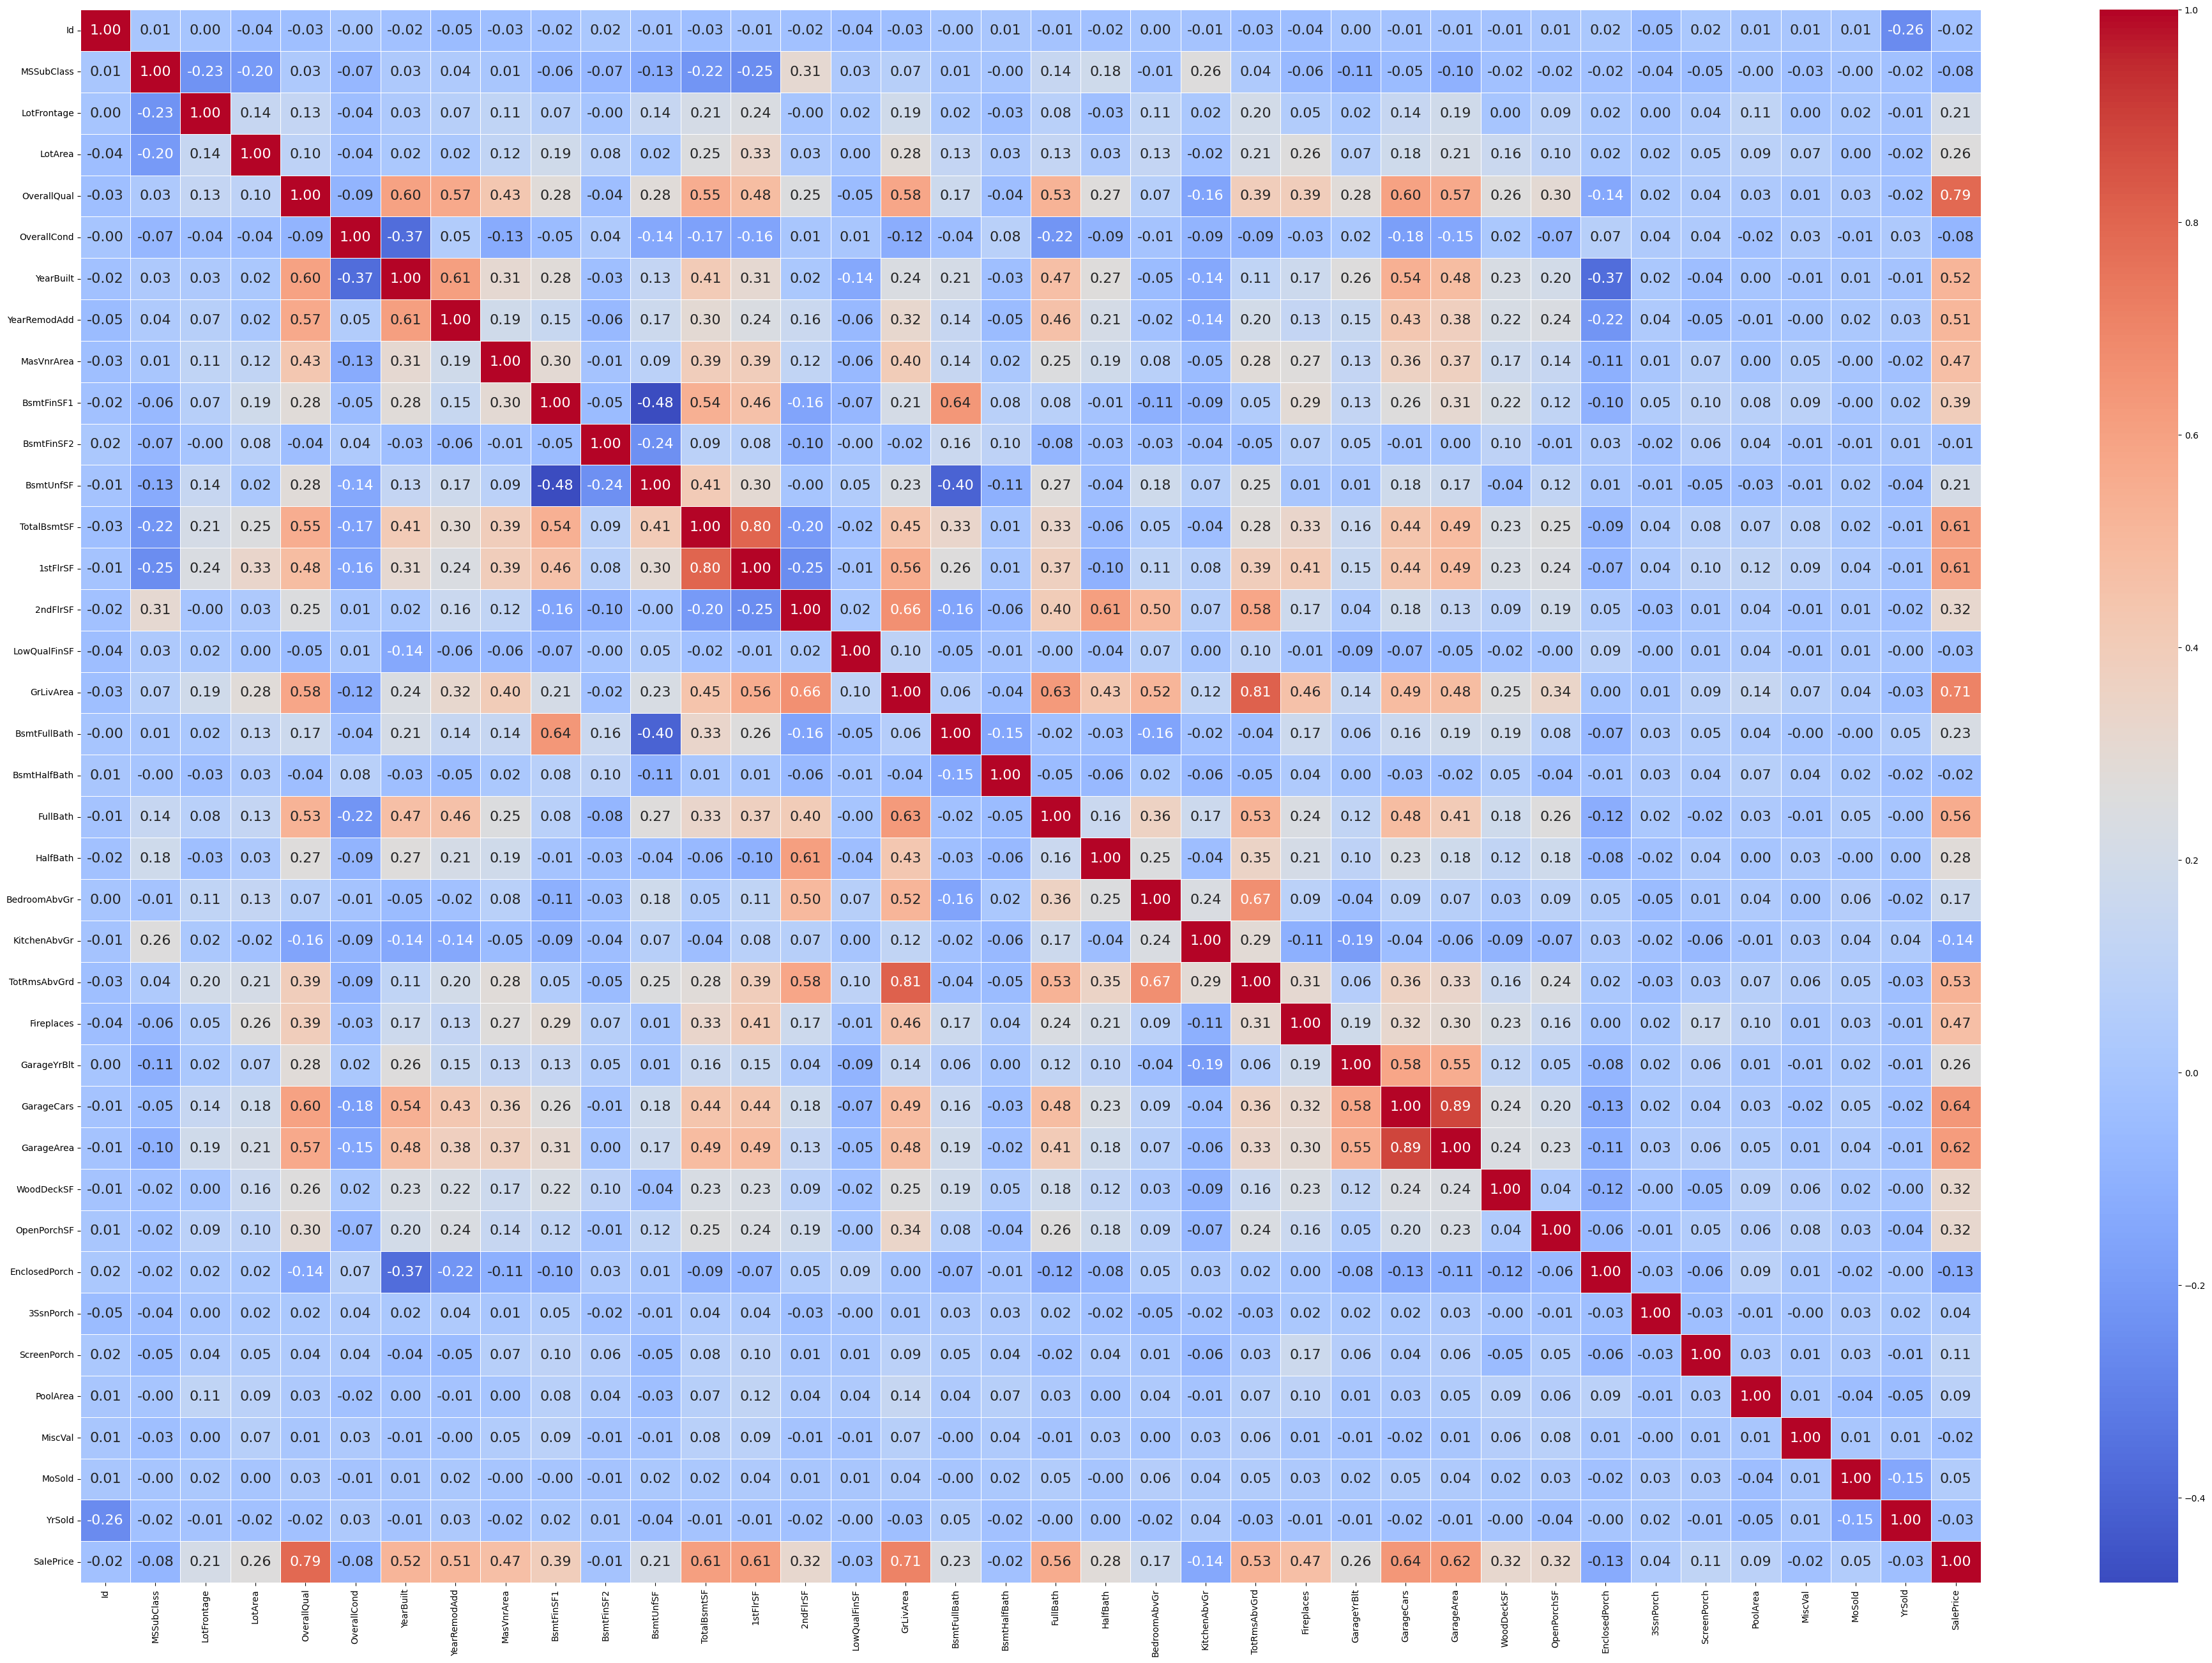

In [32]:
# Look up correlation between numeric features

# Select only numeric columns for calculating the correlation matrix
numeric_df = df.select_dtypes(include='number')

# Calculate the correlation matrix
df_corr = numeric_df.corr().round(2)

# Create a heatmap
plt.figure(figsize=(48, 32))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt="0.2f", linewidths=0.5, annot_kws={"size": 16})

plt.show()

In [33]:
# Features that have years in them
df['GarageYrBlt'] = df['YrSold'] - df['GarageYrBlt']
df['YearBuilt'] = df['YrSold'] - df['YearBuilt']
df['YearRemodAdd'] = df['YrSold'] - df['YearRemodAdd']

df.drop(['YrSold'], axis=1, inplace=True)
df.drop(['MoSold'], axis=1, inplace=True) #Isn't necessary

In [34]:
# Features that have square feet
df['BsmtFinSF'] = df['BsmtFinSF1'] + df['BsmtFinSF2']
df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']

df.drop(['BsmtFinSF1'], axis=1, inplace=True)
df.drop(['BsmtFinSF2'], axis=1, inplace=True)
df.drop(['1stFlrSF'], axis=1, inplace=True)
df.drop(['2ndFlrSF'], axis=1, inplace=True)
df.drop(['TotalBsmtSF'], axis=1, inplace=True)

In [35]:
# Features that are about bathrooms
df['TotalBaths'] = df['FullBath'] + (0.5*df['HalfBath']) + df['BsmtFullBath'] + (0.5*df['BsmtHalfBath'])

df.drop(['FullBath'], axis=1, inplace=True)
df.drop(['HalfBath'], axis=1, inplace=True)
df.drop(['BsmtFullBath'], axis=1, inplace=True)
df.drop(['BsmtHalfBath'], axis=1, inplace=True)

In [36]:
# Features about the garage
df['GarageAreaPerCar'] = df['GarageArea'] / df['GarageCars']

# Fill in any nulls from feature engineering
df.fillna({'GarageAreaPerCar': 0}, inplace=True)

df.drop(['GarageArea'], axis=1, inplace=True)
df.drop(['GarageCars'], axis=1, inplace=True)

In [37]:
df = df.drop(df[(df['GrLivArea']>4000) & (df['SalePrice']<300000)].index)

**Feature Transformation**

Feature transformation refers to the process of altering the features or variables in your dataset to make them more suitable for analysis or modeling. This transformation can involve various techniques to modify the distribution, scale, or relationships between the features. Feature transformation is a crucial step in data preprocessing, particularly in machine learning tasks, where the quality and characteristics of the input features significantly impact the performance of the models.

In [16]:
# Create a list of the numerical data types after the feature engineering
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
numerical_cols = numerical_cols.drop(['SalePrice', 'Id'])

# Create new dataframe with the numerical columns
skew_df = pd.DataFrame({'Feature': numerical_cols})

# This fonction used to compute the skewness of a dataset
skew_df['Skew'] = skew_df['Feature'].apply(
    lambda feature: scipy.stats.skew(df[feature].dropna())
)
# Change Skew to a postive number
skew_df['Absolute Skew'] = skew_df['Skew'].apply(abs)

# Create true/false columns based on if Absolute Skew is >=0.5
skew_df['Skewed'] = skew_df['Absolute Skew'].apply(lambda x: True if x >= 0.5 else False)

In [180]:
skew_df

,Feature,Skew,Absolute Skew,Skewed
0,MSSubClass,1.375457,1.375457,True
1,LotFrontage,0.022013,0.022013,False
2,LotArea,12.822431,12.822431,True
3,OverallQual,0.197110,0.197110,False
4,OverallCond,0.570312,0.570312,True
5,YearBuilt,0.598609,0.598609,True
6,YearRemodAdd,0.450226,0.450226,False
7,MasVnrArea,2.613592,2.613592,True
8,BsmtUnfSF,0.919339,0.919339,True
9,LowQualFinSF,12.088761,12.088761,True


In [17]:
# Check if a column has a min of 0 for log transformation
df[numerical_cols].describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtUnfSF,LowQualFinSF,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,57.137718,57.766701,10168.114080,6.089072,5.564577,36.479959,23.528263,101.396026,560.579993,4.694416,...,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,490.837273,1496.065433,2.218397,257.558056
std,42.517628,33.481636,7886.996359,1.409947,1.113131,30.336182,20.892061,178.854579,439.590889,46.396825,...,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,477.209821,503.675790,0.808840,86.049842
min,20.000000,0.000000,1300.000000,1.000000,1.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000
25%,20.000000,43.000000,7478.000000,5.000000,5.000000,7.000000,4.000000,0.000000,220.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1120.000000,1.500000,226.500000
50%,50.000000,63.000000,9453.000000,6.000000,5.000000,35.000000,15.000000,0.000000,467.000000,0.000000,...,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,457.000000,1440.000000,2.000000,262.666667
75%,70.000000,78.000000,11570.000000,7.000000,6.000000,54.500000,43.000000,163.500000,805.000000,0.000000,...,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,805.500000,1742.500000,2.500000,294.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,136.000000,60.000000,1600.000000,2336.000000,1064.000000,...,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,5644.000000,5642.000000,7.000000,924.000000


In [18]:
# Apply log1p transformation to df whose above a 0.5 absolute skew
for column in skew_df.query("Skewed == True")['Feature'].values:
    df[column] = np.log1p(df[column])

/workspaces/kaggle_house_compet/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


**Encoding Categorical**

In [19]:
# Get list of numerical before starting
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('SalePrice')
num_cols = num_cols.drop('Id')

In [20]:
# Get list of categorical
categorical_columns_list = df.select_dtypes(include='object').columns

# Create a new Dataframe containing only the categorical columns
df_categorical = df[categorical_columns_list].copy()

df_categorical

/tmp/ipykernel_121770/860772493.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns_list = df.select_dtypes(include='object').columns


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
1,RL,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
3,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
4,RL,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,None,None,None,None,Y,None,None,None,WD,Normal
2915,RM,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,...,CarPort,Unf,TA,TA,Y,None,None,None,WD,Abnorml
2916,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
2917,RL,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,None,None,None,None,Y,None,MnPrv,Shed,WD,Normal


The label encoder method was giving me undesirable values, for example "None" could of been a 4, so going to do it manually

In [21]:
# Label encode all the ordinal data

ordinal_1 = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_1:
    if 'None' in df[col].value_counts().index:
        df[col] = df[col].map({"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')
    else:
        df[col] = df[col].map({"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}).astype('int')

In [22]:
# Label encode all the ordinal data individually, and add to list

ordinal_2 = ['LotShape', 'LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'Utilities', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']

df['LotShape'] = df['LotShape'].map({"None":0,"IR3":1,"IR2":2,"IR1":3,"Reg":4}).astype('int')
df['LandContour'] = df['LandContour'].map({"None":0,"Low":1,"Bnk":2,"HLS":3,"Lvl":4}).astype('int')
df['LandSlope'] = df['LandSlope'].map({"None":0,"Sev":1,"Mod":2,"Gtl":3}).astype('int')
df['BsmtExposure'] = df['BsmtExposure'].map({"None":0, "No":1,"Mn":2,"Av":3,"Gd":4}).astype('int')
df['BsmtFinType1'] = df['BsmtFinType1'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['BsmtFinType2'] = df['BsmtFinType2'].map({"None":0, "Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}).astype('int')
df['Utilities'] = df['Utilities'].map({"None":0,"ELO":1,"NoSeWa":2,"NoSewr":3,"AllPub":4}).astype('int')
df['CentralAir'] = df['CentralAir'].map({"None":0,"N":1,"Y":2}).astype('int')
df['Functional'] = df['Functional'].map({"None":0,"Sal":1,"Sev":2,"Maj2":3,"Maj1":4,"Mod":5,"Min2":6,
                                         "Min1":7,"Typ":8}).astype('int')
df['GarageFinish'] = df['GarageFinish'].map({"None":0,"Unf":1,"RFn":2,"Fin":3}).astype('int')
df['PavedDrive'] = df['PavedDrive'].map({"None":0,"N":1,"P":2,"Y":3}).astype('int')
df['Fence'] = df['Fence'].map({"None":0, "MnWw":1,"GdWo":2,"MnPrv":3,"GdPrv":4}).astype('int')

In [23]:
# Get remaining non-ordinal categorical columns
df_categorical = df_categorical.drop(columns=ordinal_1)
df_categorical = df_categorical.drop(columns=ordinal_2)

# Get the rest of the categorical data for one hot encoding
ohe_ = df_categorical.columns.tolist()

# Convert categorical columns to one-hot encoded columns, dropping the first column for each
df_encoded = pd.get_dummies(df[ohe_], drop_first=True).astype(int)

# Concatenate the one-hot encoded columns with the original Dataframe
df = pd.concat([df.drop(columns=ohe_), df_encoded], axis=1)

In [236]:
processed_df = df.copy()

**Split Train and Test Data**

In [237]:
# Split the data back into train and test sets
df_train = processed_df.iloc[:df_train.shape[0]]
df_test = processed_df.iloc[df_train.shape[0]:]
df_test

,Id,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,Utilities,LandSlope,OverallQual,OverallCond,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1460,1461,3.044522,80.0,9.360741,4,4,4,3,5,1.945910,...,0,0,0,0,1,0,0,0,1,0
1461,1462,3.044522,81.0,9.565775,3,4,4,3,6,1.945910,...,0,0,0,0,1,0,0,0,1,0
1462,1463,4.110874,74.0,9.534668,3,4,4,3,5,1.791759,...,0,0,0,0,1,0,0,0,1,0
1463,1464,4.110874,78.0,9.208238,3,4,4,3,6,1.945910,...,0,0,0,0,1,0,0,0,1,0
1464,1465,4.795791,43.0,8.518392,3,3,4,3,8,1.791759,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,5.081404,21.0,7.568896,4,4,4,3,4,2.079442,...,0,0,0,0,1,0,0,0,1,0
2915,2916,5.081404,21.0,7.546974,4,4,4,3,4,1.791759,...,0,0,0,0,1,0,0,0,0,0
2916,2917,3.044522,160.0,9.903538,4,4,4,3,5,2.079442,...,0,0,0,0,1,0,0,0,0,0
2917,2918,4.454347,62.0,9.253591,4,4,4,3,5,1.791759,...,0,0,0,0,1,0,0,0,1,0


In [ ]:
# Séparer features et cible

X = df_train.drop("SalePrice", axis=1)
y = df_train["SalePrice"]
# Créer train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Target Feature Encoding**

In [239]:
df_train.drop(['Id'], axis=1, inplace=True)
df_test.drop(['SalePrice', 'Id'], axis=1, inplace=True)

Perform log transformation on SalePrice so it's less skewed

In [240]:
log_target = np.log(df_train['SalePrice'])

df_train.drop(['SalePrice'], axis=1, inplace=True)

**Optuna Parameters**

In [243]:
# Define objective function for Optuna for catboost
def objective_cat(trial):
    # Define hyperparameters to optimize
    catboost_params = {
        'iterations': trial.suggest_int('iterations', 1000, 8000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
        'depth': trial.suggest_int('depth', 3, 7),
        'eval_metric': 'RMSE',
    }

    # Initialize models with suggested parameters
    catboost_model = CatBoostRegressor(**catboost_params, verbose=0)
    
    # Train models
    catboost_model.fit(df_train, log_target)

    # Calculate RMSE
    kf = KFold(n_splits=10)
    catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))

    # Return average RMSE
    return np.mean(catboost_rmse)

In [242]:
# Define objective function for Optuna for xgboost
def objective_xgb(trial):
    # Define hyperparameters to optimize
    xgboost_params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 0.6),
        'subsample': trial.suggest_uniform('subsample', 0.4, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
    }

    # Initialize models with suggested parameters
    xgb_model = XGBRegressor(**xgboost_params, verbosity=0)

    # Train models
    xgb_model.fit(df_train, log_target)

    # Calculate RMSE
    kf = KFold(n_splits=10)
    xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))

    # Return average RMSE
    return np.mean(xgb_rmse)

In [244]:
# Optimize hyperparameters catboost
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=50, n_jobs=-1 )

: 

: 

In [ ]:
# Get best parameters
best_params_cat = study_cat.best_params

In [ ]:
best_params_cat

{'iterations': 6626, 'learning_rate': 0.007452770614322204, 'depth': 7}

In [ ]:
study_cat.best_value

1.1267413564308968

In [220]:
# best_params_cat = {
#     'iterations': 6626, 
#     'learning_rate': 0.007452770614322204, 
#     'depth': 7,
#     'eval_metric':'RMSE'
# }

best_params_cat = {
    'iterations': 6706,
     'learning_rate': 0.009963790473138256,
     'depth': 6,
     'eval_metric':'RMSE',
}



In [223]:
# Use best parameters to train final models
catboost_model = CatBoostRegressor(**best_params_cat, verbose=0)
catboost_model.fit(df_train, log_target)

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=6706, learning_rate=0.009963790473138256, loss_function='RMSE', verbose=0)

In [ ]:
# Calculate RMSE CatBoost
kf = KFold(n_splits=10)
catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [ ]:
# Return average RMSE
print(np.mean(catboost_rmse))

1.1256611748229717


In [ ]:
catb_pred = np.exp(catboost_model.predict(df_test))
catb_pred

array([115026.8312435 , 164180.95714884, 184296.70553998, ...,
       156457.27685653, 115855.22430476, 213339.90661892], shape=(1459,))

XGB

In [ ]:
# # Optimize hyperparameters xgboost
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=50)

In [ ]:
best_params_xgb = study_xgb.best_params

In [ ]:
best_params_xgb

{'n_estimators': 4492,
 'learning_rate': 0.012109563196185589,
 'colsample_bytree': 0.4693337159315575,
 'subsample': 0.4395213597260866,
 'min_child_weight': 4}

In [ ]:
study_xgb.best_value

1.1278363711240071

**Forming and Testing the Model**

In [221]:
best_params_xgb = {
    'n_estimators': 6696,
    'learning_rate': 0.00630,
    'colsample_bytree': 0.22301,
    'subsample': 0.45878,
    'min_child_weight': 3,
}

In [222]:
xgb_model = XGBRegressor(**best_params_xgb, verbosity=0)
xgb_model.fit(df_train, log_target)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.22301
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabe

In [ ]:
xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_train, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [ ]:
# Return average RMSE
# print(np.mean(xgb_rmse))

1.1267729939641922


In [ ]:
xgb_pred = np.exp(xgb_model.predict(df_test))

In [ ]:
xgb_pred

array([114328.76, 163287.12, 187486.53, ..., 170889.9 , 111758.75,
       207441.42], shape=(1459,), dtype=float32)

In [ ]:
def objective_lasso(trial):
    # On cherche alpha sur une échelle logarithmique
    alpha = trial.suggest_float('alpha', 0.0001, 0.01, log=True)
    
    # Création du pipeline (Indispensable de scaler pour Lasso)
    lasso_model = make_pipeline(RobustScaler(), Lasso(alpha=alpha, random_state=42))
    
    # Cross-validation
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    # On calcule la RMSE sur le log_target
    rmse_scores = np.sqrt(-cross_val_score(lasso_model, df_train, log_target, 
                                           scoring='neg_mean_squared_error', cv=kf))
    
    return np.mean(rmse_scores)

In [ ]:
# Combine predictions
final_predictions = (
    0.80 * np.exp(catboost_model.predict(df_test)) + 
    0.20 * np.exp(xgb_model.predict(df_test))
)

final_predictions

array([114887.21694793, 164002.19150032, 184934.67302573, ...,
       159343.80195397, 115035.92944381, 212160.21045138], shape=(1459,))

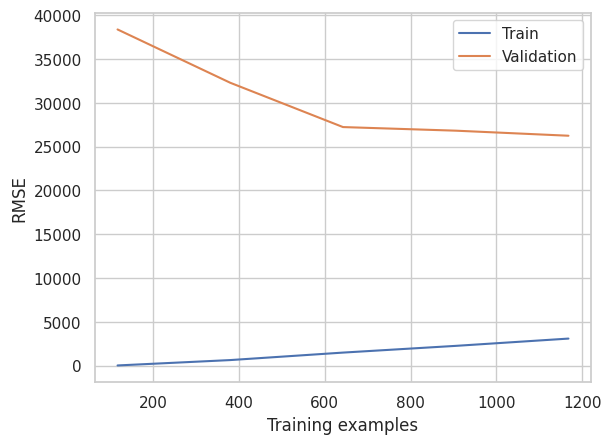

In [ ]:
# # df.iloc[df_train.shape[0]:]
# # X_train, X_val, y_train, y_val


# train_sizes = np.linspace(0.1, 1.0, 5)
# train_scores, val_scores = [], []

# for frac in train_sizes:
#     n = int(frac * len(X_train))
#     X_sub, y_sub = X_train.iloc[:n], y_train.iloc[:n]
    
#     # Entraînement des modèles
#     catboost_model.fit(X_sub, y_sub)
#     xgb_model.fit(X_sub, y_sub)
    
#     # Prédictions combinées
#     y_train_pred = 0.8*catboost_model.predict(X_sub) + 0.2*xgb_model.predict(X_sub)
#     y_val_pred   = 0.8*catboost_model.predict(X_val) + 0.2*xgb_model.predict(X_val)
    
#     # Calcul RMSE
#     train_scores.append(np.sqrt(mean_squared_error(y_sub, y_train_pred)))
#     val_scores.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

# # Trace
# plt.plot(train_sizes*len(X_train), train_scores, label="Train")
# plt.plot(train_sizes*len(X_train), val_scores, label="Validation")
# plt.xlabel("Training examples")
# plt.ylabel("RMSE")
# plt.legend()
# plt.show()

**Submission**

In [ ]:
# # Save test predictions to file
# output = pd.DataFrame({'Id': df_test.index+1, 'SalePrice': catb_pred})
# output.to_csv('submission_9.csv', index=False)

In [ ]:
# output